In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame setup
data = {
    'date': ["2024-06-28", "2024-06-28", "2024-07-01", "2024-07-01", 
             "2024-07-02", "2024-07-02", "2024-07-31", "2024-07-31", 
             "2024-08-02", "2024-08-02", "2024-08-05", "2024-08-05", 
             "2024-08-30", "2024-08-30", "2024-09-03", "2024-09-03"],
    'symbol': ["AAPL", "PANW", "AAPL", "PANW", "AAPL", "PANW", 
               "AAPL", "PANW", "AAPL", "PANW", "AAPL", "PANW", 
               "AAPL", "PANW", "AAPL", "PANW"],
    'close': [210.62, 339.01, 216.75, 340.9, 220.27, 340.44, 222.08, 
              324.73, 219.86, 305.6, 209.27, 294.18, 229.0, 362.72, 
              222.77, 355.07]
}
df = pd.DataFrame(data)

# Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'])

# Create a 'year_month' column for grouping
df['year_month'] = df['date'].dt.to_period('M')

# Calculate the first available price for each symbol at the start of each month
monthly_first_available = df.groupby(['symbol', 'year_month']).first().reset_index()

# Rename the 'close' column in monthly_first_available
monthly_first_available = monthly_first_available.rename(columns={'close': 'first_available_price'})

# Merge the first available price back into the original DataFrame
df = df.merge(
    monthly_first_available[['symbol', 'year_month', 'first_available_price']],
    on=['symbol', 'year_month'],
    how='left'
)

# Get the current month and filter the data
current_month = pd.Timestamp.today().to_period('M')

# Initialize previous month's first price for each symbol
prev_month_prices = df[['symbol', 'year_month', 'first_available_price']].copy()

# Function to calculate monthly increase
def calculate_monthly_increase(row):
    # Filter data for the current month
    current_month_data = df[(df['year_month'] == current_month) & (df['symbol'] == row['symbol'])]
    
    if row['year_month'] == current_month:
        if len(current_month_data) > 1:
            # For current month, compare the latest price with the first price of the current month
            first_price_current_month = current_month_data['first_available_price'].iloc[0]
            return row['close'] - first_price_current_month
        else:
            # Compare the first price of the current month with the previous month's price
            prev_month_data = prev_month_prices[(prev_month_prices['symbol'] == row['symbol']) & (prev_month_prices['year_month'] < row['year_month'])]
            if not prev_month_data.empty:
                prev_month_price = prev_month_data['first_available_price'].max()
                return row['close'] - prev_month_price
    else:
        # For previous months, compare with the first available price of the previous month
        prev_month_data = prev_month_prices[(prev_month_prices['symbol'] == row['symbol']) & (prev_month_prices['year_month'] < row['year_month'])]
        if not prev_month_data.empty:
            prev_month_price = prev_month_data['first_available_price'].max()
            return row['first_available_price'] - prev_month_price
    return None

# Apply the function to calculate the monthly increase for each row
df['monthly_increase'] = df.apply(calculate_monthly_increase, axis=1)

# Step 1: Filter the dataframe to keep only the latest date for each symbol and month, but skip the current month
df_previous_months = df[df['year_month'] != current_month]
df_previous_months = df_previous_months.loc[df_previous_months.groupby(['symbol', 'year_month'])['date'].idxmax()]

# Display the results
#print(df)

# Step 2: Handle the current month separately by keeping all records initially
current_month_data = df[df['year_month'] == current_month]

if not current_month_data.empty:
    #latest_current_month_data = current_month_data.iloc[-1:]
    latest_current_month_data = current_month_data.loc[current_month_data.groupby(['symbol', 'year_month'])['date'].idxmax()]
    #df = pd.concat([df[df['year_month'] != current_month], latest_current_month_data])
    df = pd.concat([df_previous_months, latest_current_month_data])

# Remove unnecessary columns
df = df[['symbol', 'date', 'close', 'first_available_price', 'monthly_increase']]

# Display the results
print(df)


   symbol       date   close  first_available_price  monthly_increase
0    AAPL 2024-06-28  210.62                 210.62               NaN
6    AAPL 2024-07-31  222.08                 216.75              6.13
12   AAPL 2024-08-30  229.00                 219.86              3.11
1    PANW 2024-06-28  339.01                 339.01               NaN
7    PANW 2024-07-31  324.73                 340.90              1.89
13   PANW 2024-08-30  362.72                 305.60            -35.30
14   AAPL 2024-09-03  222.77                 222.77              2.91
15   PANW 2024-09-03  355.07                 355.07             14.17


In [76]:
# Convert 'date' to datetime format and create a 'year_month' column for grouping
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

# Convert 'year_month' to string for proper ordering in plot
df['year_month_str'] = df['year_month'].astype(str)

# Fill NaN values
df['monthly_increase'] = df['monthly_increase'].fillna(0)

# Ensure 'year_month_str' is treated as categorical with a specific order
df['year_month_str'] = pd.Categorical(df['year_month_str'], categories=sorted(df['year_month_str'].unique()), ordered=True)

# Aggregate data
agg_df = df.groupby(['year_month_str', 'symbol']).agg(
    total_monthly_increase=('monthly_increase', 'sum'),
    avg_percentage_increase=('monthly_increase', 'mean')
).reset_index()



/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_43240/2059517020.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby(['year_month_str', 'symbol']).agg(


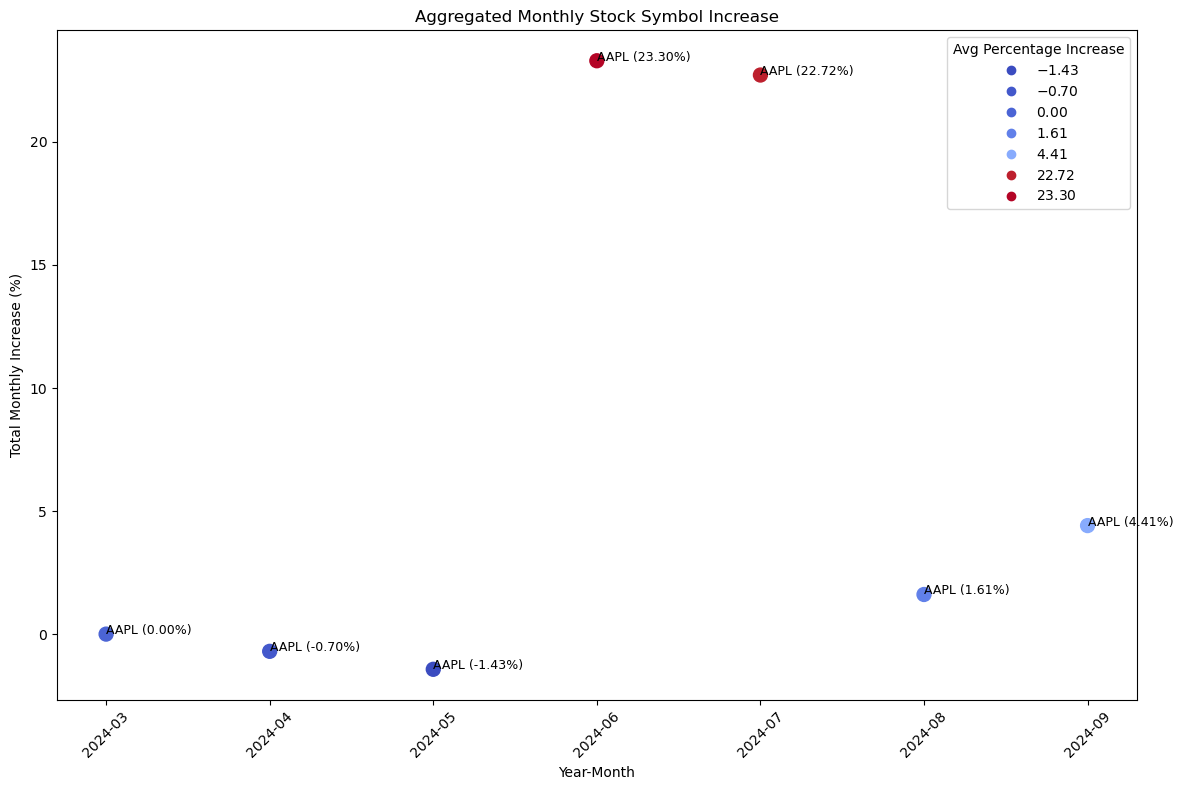

In [77]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(
    agg_df['year_month_str'],
    agg_df['total_monthly_increase'],
    c=agg_df['avg_percentage_increase'],
    cmap='coolwarm',
    s=100
)

# Add labels
for i, row in agg_df.iterrows():
    ax.text(row['year_month_str'], row['total_monthly_increase'], f"{row['symbol']} ({row['avg_percentage_increase']:.2f}%)", fontsize=9)

# Formatting
ax.set_xticks(agg_df['year_month_str'].cat.categories)
ax.set_xticklabels(agg_df['year_month_str'].cat.categories, rotation=45)
ax.set_title('Aggregated Monthly Stock Symbol Increase')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Total Monthly Increase (%)')
ax.legend(*scatter.legend_elements(), title='Avg Percentage Increase')

plt.tight_layout()
plt.show()